In [1]:
%matplotlib inline

# Level of Employment

* **Input**: cleaned and optimized pickeled DataFrames (persons.csv) for 20XX, BSF age predictions
* **Output**: Visualisations

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Settings" data-toc-modified-id="Settings-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Settings</a></span></li><li><span><a href="#Loading-Data" data-toc-modified-id="Loading-Data-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Loading Data</a></span><ul class="toc-item"><li><span><a href="#SynPop" data-toc-modified-id="SynPop-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>SynPop</a></span></li><li><span><a href="#BFS-Erwerbsbewölkerung" data-toc-modified-id="BFS-Erwerbsbewölkerung-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>BFS Erwerbsbewölkerung</a></span></li></ul></li><li><span><a href="#Analysis" data-toc-modified-id="Analysis-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Analysis</a></span><ul class="toc-item"><li><span><a href="#Globally" data-toc-modified-id="Globally-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Globally</a></span></li><li><span><a href="#Per-Age" data-toc-modified-id="Per-Age-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Per Age</a></span><ul class="toc-item"><li><span><a href="#Scenario-Year" data-toc-modified-id="Scenario-Year-3.2.1"><span class="toc-item-num">3.2.1&nbsp;&nbsp;</span>Scenario-Year</a></span></li><li><span><a href="#IST" data-toc-modified-id="IST-3.2.2"><span class="toc-item-num">3.2.2&nbsp;&nbsp;</span>IST</a></span></li></ul></li></ul></li><li><span><a href="#Export-Notebook-to-HTML" data-toc-modified-id="Export-Notebook-to-HTML-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Export Notebook to HTML</a></span></li></ul></div>

In [2]:
import logging
import os
import sys
import pandas as pd

from matplotlib import pyplot as plt

In [3]:
sys.path.append(r'\\Filer16L\P-V160L\SIMBA.A11244\90_Persoenlich\u229285\dev\SynPopToolbox')

In [4]:
from synpop.marginals import FSO_ActivePopPredictionsClient
from synpop.visualisations import plot_people_employed_by_age
import synpop.utils as utils

##  Settings

In [5]:
YEAR_IST = 2017
YEAR = 2030

DATA_DIR_IST = r'\\k13536\mobi\10_Daten\SynPop\2017\190813_CH_2017_BEST1\02_preprocessed'
SYNPOP_PERSONS_FILE_IST = os.path.join(DATA_DIR_IST, 'persons_{}.pickle.gzip'.format(YEAR_IST))

DATA_DIR = r'\\k13536\mobi\10_Daten\SynPop\2030\02_preprocessed'
SYNPOP_PERSONS_FILE = os.path.join(DATA_DIR, 'persons_{}.pickle.gzip'.format(YEAR))

**Plot Export Settings**

In [6]:
SAVE_FIGURES = True
OUTPUT_DIR = './outputs'
FIG_FORMAT = 'png'
FIG_DPI = 150
FIG_BBOX_INCHES = 'tight'
FIG_PAD_INCHES = 0.2

In [7]:
utils.create_dir(OUTPUT_DIR)

2020-02-18 10:06:15,888 - INFO - synpop.utils: "./outputs" exists already


## Loading Data

### SynPop

In [8]:
SYNPOP_PERSONS_FILE

'\\\\k13536\\mobi\\10_Daten\\SynPop\\2030\\02_preprocessed\\persons_2030.pickle.gzip'

In [9]:
%%time
persons = pd.read_pickle(SYNPOP_PERSONS_FILE, compression='gzip') 

# level of employment
labels = ['0%', 'part_time', '100%']
persons['loe'] = pd.cut(persons['level_of_employment'], bins=(-0.01, 0, 99.9, 100), labels=labels)

Wall time: 15.4 s


In [10]:
SYNPOP_PERSONS_FILE_IST

'\\\\k13536\\mobi\\10_Daten\\SynPop\\2017\\190813_CH_2017_BEST1\\02_preprocessed\\persons_2017.pickle.gzip'

In [11]:
%%time
persons_ist = pd.read_pickle(SYNPOP_PERSONS_FILE_IST, compression='gzip') 

# level of employment
labels = ['0%', 'part_time', '100%']
persons_ist['loe'] = pd.cut(persons_ist['level_of_employment'], bins=(-0.01, 0, 99.9, 100), labels=labels)

Wall time: 11.9 s


### BFS Erwerbsbewölkerung

**Personnes active = personnes actives occupées + chômeurs**

**Global**

In [12]:
active_pop = FSO_ActivePopPredictionsClient(granularity='global').load(YEAR)
active_pop_stats_global = active_pop.stats

In [13]:
active_pop_stats_global

,active_people,active_people_fte,avg_active_people,avg_fte_per_person
0,5208397,4499952,54.586939,47.16204


**By Age**

In [14]:
active_pop_client = FSO_ActivePopPredictionsClient(granularity='age').load(YEAR)
active_pop_stats_by_age = active_pop_client.stats

In [15]:
active_pop_client = FSO_ActivePopPredictionsClient(granularity='age').load(YEAR_IST)
active_pop_stats_by_age_ist = active_pop_client.stats

## Analysis

### Globally

**Level of Activity**

In [16]:
active_pop_stats_global['avg_active_people']

0    54.586939
Name: avg_active_people, dtype: float64

In [17]:
(persons['level_of_employment'] > 0).mean()

0.667305345313371

The difference could be explained by job seekers.

### Per Age

#### Scenario-Year

2020-02-18 10:06:53,633 - INFO - root: Figure saved to file : ./outputs\04-01_SynPop2030_vs_BFS_level_of_employment.png


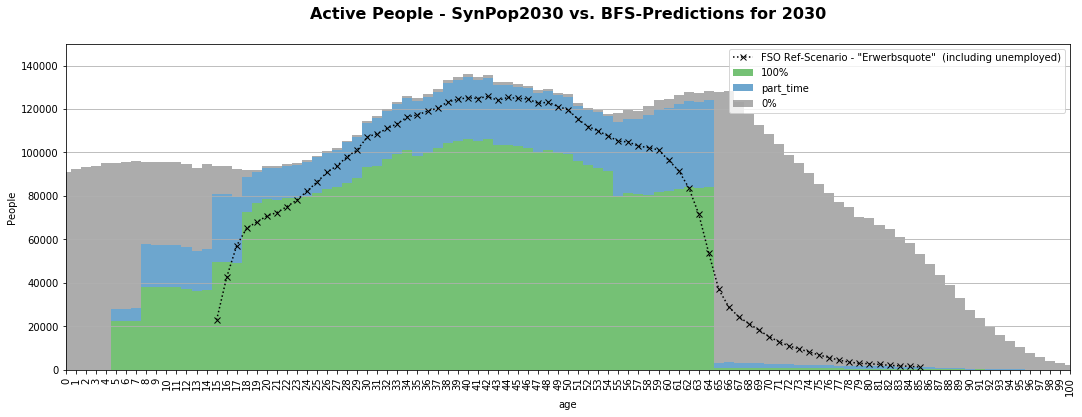

In [18]:
title = 'Active People - SynPop{year} vs. BFS-Predictions for {year}'.format(year=YEAR)
ax = plot_people_employed_by_age(persons, active_pop_stats_by_age['active_people'], title=title)

if SAVE_FIGURES:
    fig_file_name = '04-01_SynPop{}_vs_BFS_level_of_employment.{}'.format(YEAR, FIG_FORMAT)
    fig_file_path = os.path.join(OUTPUT_DIR, fig_file_name)
    plt.savefig(fig_file_path, dpi=FIG_DPI, format=FIG_FORMAT, bbox_inches=FIG_BBOX_INCHES, pad_inches=FIG_PAD_INCHES)
    logging.info('Figure saved to file : {}'.format(fig_file_path))

#### IST 

2020-02-18 10:07:00,798 - INFO - root: Figure saved to file : ./outputs\04-02_SynPop2017_vs_BFS_level_of_employment.png


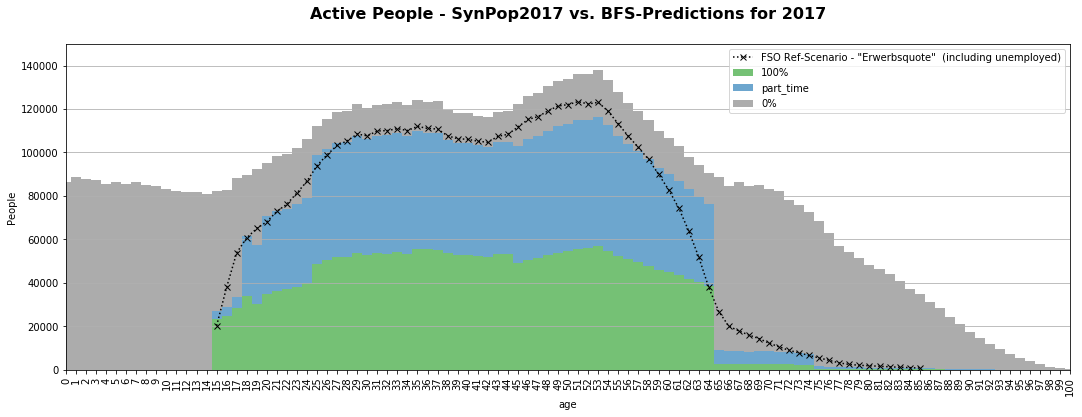

In [19]:
title = 'Active People - SynPop{year} vs. BFS-Predictions for {year}'.format(year=YEAR_IST)
ax = plot_people_employed_by_age(persons_ist, active_pop_stats_by_age_ist['active_people'], title=title)

if SAVE_FIGURES:
    fig_file_name = '04-02_SynPop{}_vs_BFS_level_of_employment.{}'.format(YEAR_IST, FIG_FORMAT)
    fig_file_path = os.path.join(OUTPUT_DIR, fig_file_name)
    plt.savefig(fig_file_path, dpi=FIG_DPI, format=FIG_FORMAT, bbox_inches=FIG_BBOX_INCHES, pad_inches=FIG_PAD_INCHES)
    logging.info('Figure saved to file : {}'.format(fig_file_path))

## Export Notebook to HTML

In [20]:
### Write notebook to a html file
!jupyter nbconvert --to html 04_Level_of_Employment.ipynb

[NbConvertApp] Converting notebook 04_Level_of_Employment.ipynb to html
[NbConvertApp] Writing 410358 bytes to 04_Level_of_Employment.html
